In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_excel("prosper_ann_cleaned.xlsx")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (43366, 12)


,StatedMonthlyIncome,DebtToIncomeRatio,CreditScoreRangeLower,BankcardUtilization,AvailableBankcardCredit,RevolvingCreditBalance,AmountDelinquent,DelinquenciesLast7Years,LoanOriginalAmount,BorrowerRate,RealizedInterestRatio,NetPrincipalLossRatio
0,3083.333333,0.17,640,0.00,1500,0,472,4,9425,0.1580,0.209140,0.000000
1,1666.666667,0.27,640,0.32,2580,1220,2224,1,1000,0.1325,0.011650,0.000000
2,5500.000000,0.49,700,0.97,178,9103,0,0,4000,0.3177,0.077845,0.947562
3,3750.000000,0.09,620,0.08,1366,134,5200,5,3000,0.2075,0.353683,0.000000
4,2500.000000,0.39,680,0.84,607,7975,0,0,2000,0.2419,0.059140,0.941135


In [3]:
input_columns = [
    "StatedMonthlyIncome",
    "DebtToIncomeRatio",
    "CreditScoreRangeLower",
    "BankcardUtilization",
    "AvailableBankcardCredit",
    "RevolvingCreditBalance",
    "AmountDelinquent",
    "DelinquenciesLast7Years",
    "LoanOriginalAmount",
    "BorrowerRate"
]

output_columns = [
    "RealizedInterestRatio",
    "NetPrincipalLossRatio"
]

X = df[input_columns].copy()
Y = df[output_columns].copy()

print("X shape:", X.shape)
print("Y shape:", Y.shape)

X shape: (43366, 10)
Y shape: (43366, 2)


In [6]:
# First split:
# 70% training
# 30% temporary

X_train, X_temp, Y_train, Y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42
)

# Split temporary dataset equally:
# 15% validation
# 15% testing

X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp,
    Y_temp,
    test_size=0.50,
    random_state=42
)

print("Training:")
print(X_train.shape, Y_train.shape)

print("\nValidation:")
print(X_val.shape, Y_val.shape)

print("\nTesting:")
print(X_test.shape, Y_test.shape)

Training:
(30356, 10) (30356, 2)

Validation:
(6505, 10) (6505, 2)

Testing:
(6505, 10) (6505, 2)


In [7]:
X_train_min = X_train.min()
X_train_max = X_train.max()

Y_train_min = Y_train.min()
Y_train_max = Y_train.max()

print("X Training Minimums:")
print(X_train_min)

print("\nX Training Maximums:")
print(X_train_max)

print("\nY Training Minimums:")
print(Y_train_min)

print("\nY Training Maximums:")
print(Y_train_max)

X Training Minimums:
StatedMonthlyIncome           0.083333
DebtToIncomeRatio             0.000000
CreditScoreRangeLower       520.000000
BankcardUtilization           0.000000
AvailableBankcardCredit       0.000000
RevolvingCreditBalance        0.000000
AmountDelinquent              0.000000
DelinquenciesLast7Years       0.000000
LoanOriginalAmount         1000.000000
BorrowerRate                  0.000000
dtype: float64

X Training Maximums:
StatedMonthlyIncome        4.833333e+05
DebtToIncomeRatio          1.001000e+01
CreditScoreRangeLower      8.800000e+02
BankcardUtilization        5.950000e+00
AvailableBankcardCredit    5.724270e+05
RevolvingCreditBalance     1.435667e+06
AmountDelinquent           3.276770e+05
DelinquenciesLast7Years    9.900000e+01
LoanOriginalAmount         3.500000e+04
BorrowerRate               3.600000e-01
dtype: float64

Y Training Minimums:
RealizedInterestRatio   -0.000783
NetPrincipalLossRatio   -0.109420
dtype: float64

Y Training Maximums:
RealizedIn

In [8]:
X_train_scaled = (
    (X_train - X_train_min) /
    (X_train_max - X_train_min)
)

X_val_scaled = (
    (X_val - X_train_min) /
    (X_train_max - X_train_min)
)

X_test_scaled = (
    (X_test - X_train_min) /
    (X_train_max - X_train_min)
)

print("X normalization completed.")

X normalization completed.


In [9]:
Y_train_scaled = (
    (Y_train - Y_train_min) /
    (Y_train_max - Y_train_min)
)

Y_val_scaled = (
    (Y_val - Y_train_min) /
    (Y_train_max - Y_train_min)
)

Y_test_scaled = (
    (Y_test - Y_train_min) /
    (Y_train_max - Y_train_min)
)

print("Y normalization completed.")

Y normalization completed.


In [10]:
print("TRAIN X:")
print("Min =", X_train_scaled.min().min())
print("Max =", X_train_scaled.max().max())

print("\nVALIDATION X:")
print("Min =", X_val_scaled.min().min())
print("Max =", X_val_scaled.max().max())

print("\nTEST X:")
print("Min =", X_test_scaled.min().min())
print("Max =", X_test_scaled.max().max())


print("\nTRAIN Y:")
print("Min =", Y_train_scaled.min().min())
print("Max =", Y_train_scaled.max().max())

print("\nVALIDATION Y:")
print("Min =", Y_val_scaled.min().min())
print("Max =", Y_val_scaled.max().max())

print("\nTEST Y:")
print("Min =", Y_test_scaled.min().min())
print("Max =", Y_test_scaled.max().max())

TRAIN X:
Min = 0.0
Max = 1.0

VALIDATION X:
Min = -1.7241313317467815e-07
Max = 1.0

TEST X:
Min = -1.7241313317467815e-07
Max = 1.3572664544658306

TRAIN Y:
Min = 0.0
Max = 1.0

VALIDATION Y:
Min = -0.06315460874108346
Max = 0.9999961804334385

TEST Y:
Min = -0.32890271260163667
Max = 0.9999760137421424


In [11]:
X_train_nn = X_train_scaled.to_numpy()
X_val_nn = X_val_scaled.to_numpy()
X_test_nn = X_test_scaled.to_numpy()

Y_train_nn = Y_train_scaled.to_numpy()
Y_val_nn = Y_val_scaled.to_numpy()
Y_test_nn = Y_test_scaled.to_numpy()

print(X_train_nn.shape)
print(Y_train_nn.shape)

(30356, 10)
(30356, 2)


In [12]:
model = Sequential()

model.add(
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_nn.shape[1],)
    )
)

model.add(
    Dense(
        32,
        activation="relu"
    )
)

model.add(
    Dense(
        2,
        activation="linear"
    )
)

model.summary()


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                704       
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 2)                 66        
                                                                 
Total params: 2850 (11.13 KB)
Trainable params: 2850 (11.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [13]:
optimizer = Adam(
    learning_rate=0.001
)

model.compile(
    optimizer=optimizer,
    loss="mse"
)

print("Model compiled.")

Model compiled.


In [24]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

history = model.fit(
    X_train_nn,
    Y_train_nn,
    validation_data=(X_val_nn, Y_val_nn),
    epochs=150,
    batch_size=32,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/150
949/949 [==============================] - 4s 4ms/step - loss: 0.0466 - val_loss: 0.0470
Epoch 2/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0467 - val_loss: 0.0471
Epoch 3/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0467 - val_loss: 0.0468
Epoch 4/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0467 - val_loss: 0.0467
Epoch 5/150
949/949 [==============================] - 4s 4ms/step - loss: 0.0466 - val_loss: 0.0468
Epoch 6/150
949/949 [==============================] - 3s 4ms/step - loss: 0.0467 - val_loss: 0.0467
Epoch 7/150
949/949 [==============================] - 4s 4ms/step - loss: 0.0466 - val_loss: 0.0467
Epoch 8/150
949/949 [==============================] - 5s 5ms/step - loss: 0.0466 - val_loss: 0.0467
Epoch 9/150
949/949 [==============================] - 5s 5ms/step - loss: 0.0466 - val_loss: 0.0466
Epoch 10/150
949/949 [==============================] - 4s 4ms/step - loss: 0.0465 - val_lo

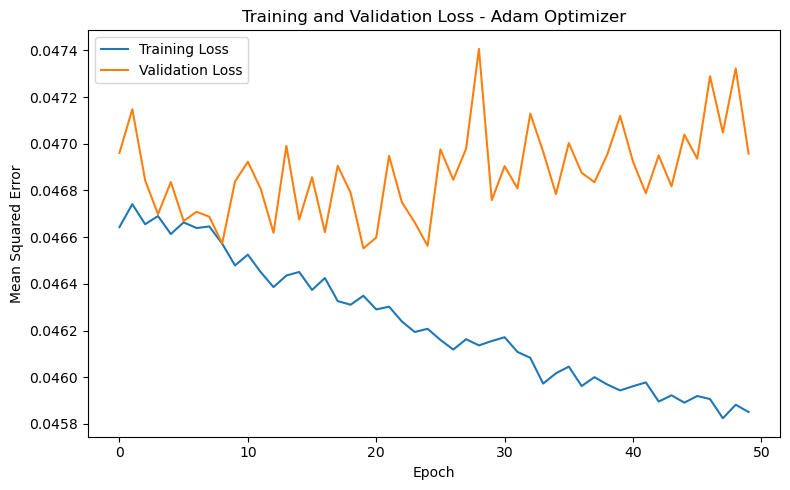

In [25]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation Loss - Adam Optimizer")

plt.legend()
plt.tight_layout()

plt.savefig(
    "adam_training_validation_loss.png",
    dpi=300
)

plt.show()

In [26]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
best_val_loss = np.min(history.history["val_loss"])

print("Epochs actually trained:", len(history.history["loss"]))
print("Best epoch:", best_epoch)
print("Best validation MSE:", best_val_loss)

Epochs actually trained: 50
Best epoch: 20
Best validation MSE: 0.04655173420906067


In [27]:
Y_train_pred = model.predict(
    X_train_nn,
    verbose=0
)

In [28]:
Y_test_pred = model.predict(
    X_test_nn,
    verbose=0
)

In [29]:
train_mse = mean_squared_error(
    Y_train_nn,
    Y_train_pred
)

train_r2 = r2_score(
    Y_train_nn,
    Y_train_pred
)

print("Overall Training MSE:", train_mse)
print("Overall Training R2 :", train_r2)

Overall Training MSE: 0.04595276154661213
Overall Training R2 : 0.23626640082774847


In [30]:
print("Realized Interest Ratio")

print(
    "MSE:",
    mean_squared_error(
        Y_train_nn[:, 0],
        Y_train_pred[:, 0]
    )
)

print(
    "R2:",
    r2_score(
        Y_train_nn[:, 0],
        Y_train_pred[:, 0]
    )
)


print("\nNet Principal Loss Ratio")

print(
    "MSE:",
    mean_squared_error(
        Y_train_nn[:, 1],
        Y_train_pred[:, 1]
    )
)

print(
    "R2:",
    r2_score(
        Y_train_nn[:, 1],
        Y_train_pred[:, 1]
    )
)

Realized Interest Ratio
MSE: 0.006841351077675781
R2: 0.3278267696646612

Net Principal Loss Ratio
MSE: 0.08506417201554821
R2: 0.14470603199083865


In [31]:
test_mse = mean_squared_error(
    Y_test_nn,
    Y_test_pred
)

test_r2 = r2_score(
    Y_test_nn,
    Y_test_pred
)

print("Overall Testing MSE:", test_mse)
print("Overall Testing R2 :", test_r2)

Overall Testing MSE: 0.047223608346700564
Overall Testing R2 : 0.21763098292238608


In [32]:
print("Realized Interest Ratio")

print(
    "MSE:",
    mean_squared_error(
        Y_test_nn[:, 0],
        Y_test_pred[:, 0]
    )
)

print(
    "R2:",
    r2_score(
        Y_test_nn[:, 0],
        Y_test_pred[:, 0]
    )
)


print("\nNet Principal Loss Ratio")

print(
    "MSE:",
    mean_squared_error(
        Y_test_nn[:, 1],
        Y_test_pred[:, 1]
    )
)

print(
    "R2:",
    r2_score(
        Y_test_nn[:, 1],
        Y_test_pred[:, 1]
    )
)

Realized Interest Ratio
MSE: 0.007000525365396023
R2: 0.3127628171588267

Net Principal Loss Ratio
MSE: 0.08744669132800521
R2: 0.12249914868594314


In [33]:
Y_min = Y_train_min.to_numpy()
Y_max = Y_train_max.to_numpy()

Y_train_original = (
    Y_train_nn * (Y_max - Y_min)
    + Y_min
)

Y_train_pred_original = (
    Y_train_pred * (Y_max - Y_min)
    + Y_min
)

Y_test_original = (
    Y_test_nn * (Y_max - Y_min)
    + Y_min
)

Y_test_pred_original = (
    Y_test_pred * (Y_max - Y_min)
    + Y_min
)

print("Inverse normalization completed.")

Inverse normalization completed.


In [36]:
print("NOW TRAINING THE SAME NETWORK USING RMSPROP OPTIMIZER")

NOW TRAINING THE SAME NETWORK USING RMSPROP OPTIMIZER


In [37]:
from tensorflow.keras.optimizers import RMSprop

In [38]:
rms_model = Sequential()

# Hidden Layer 1
rms_model.add(
    Dense(
        64,
        activation="relu",
        input_shape=(X_train_nn.shape[1],)
    )
)

# Hidden Layer 2
rms_model.add(
    Dense(
        32,
        activation="relu"
    )
)

# Output Layer
rms_model.add(
    Dense(
        2,
        activation="linear"
    )
)

rms_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_3 (Dense)             (None, 64)                704       
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                                 
 dense_5 (Dense)             (None, 2)                 66        
                                                                 
Total params: 2850 (11.13 KB)
Trainable params: 2850 (11.13 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [39]:
rms_optimizer = RMSprop(
    learning_rate=0.001
)

rms_model.compile(
    optimizer=rms_optimizer,
    loss="mse"
)

print("Optimizer: RMSProp")
print("Learning rate: 0.001")
print("Loss function: MSE")

Optimizer: RMSProp
Learning rate: 0.001
Loss function: MSE


In [41]:
rms_early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=30,
    restore_best_weights=True
)

In [42]:
rms_history = rms_model.fit(
    X_train_nn,
    Y_train_nn,
    validation_data=(X_val_nn, Y_val_nn),
    epochs=150,
    batch_size=32,
    callbacks=[rms_early_stopping],
    verbose=1
)

Epoch 1/150
949/949 [==============================] - 6s 5ms/step - loss: 0.0491 - val_loss: 0.0484
Epoch 2/150
949/949 [==============================] - 4s 4ms/step - loss: 0.0483 - val_loss: 0.0476
Epoch 3/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0482 - val_loss: 0.0474
Epoch 4/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0481 - val_loss: 0.0475
Epoch 5/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0480 - val_loss: 0.0477
Epoch 6/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0479 - val_loss: 0.0477
Epoch 7/150
949/949 [==============================] - 3s 4ms/step - loss: 0.0478 - val_loss: 0.0473
Epoch 8/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0477 - val_loss: 0.0472
Epoch 9/150
949/949 [==============================] - 3s 4ms/step - loss: 0.0476 - val_loss: 0.0469
Epoch 10/150
949/949 [==============================] - 3s 3ms/step - loss: 0.0476 - val_lo

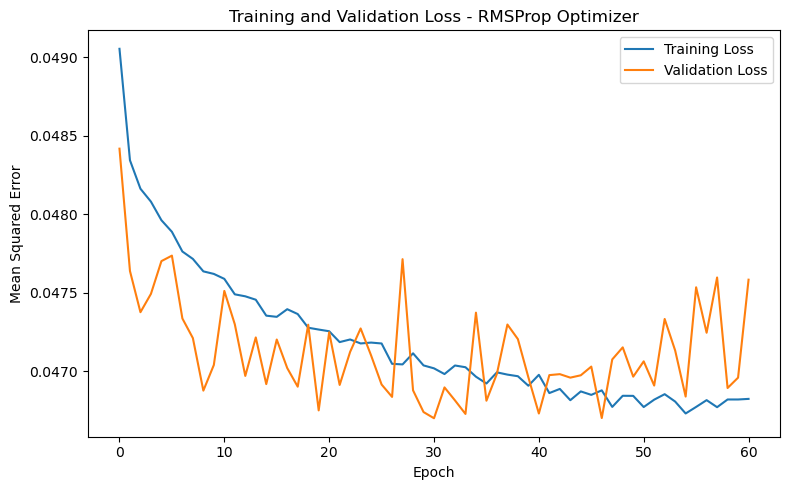

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(
    rms_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    rms_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Mean Squared Error")
plt.title("Training and Validation Loss - RMSProp Optimizer")

plt.legend()
plt.tight_layout()

plt.savefig(
    "rmsprop_training_validation_loss.png",
    dpi=300
)

plt.show()

In [46]:
rms_best_epoch = np.argmin(
    rms_history.history["val_loss"]
) + 1

rms_best_val_loss = np.min(
    rms_history.history["val_loss"]
)

print(
    "Epochs actually trained:",
    len(rms_history.history["loss"])
)

print(
    "Best epoch:",
    rms_best_epoch
)

print(
    "Best validation MSE:",
    rms_best_val_loss
)

Epochs actually trained: 61
Best epoch: 31
Best validation MSE: 0.04670229181647301


In [47]:
Y_train_pred_rms = rms_model.predict(
    X_train_nn,
    verbose=0
)

In [48]:
Y_test_pred_rms = rms_model.predict(
    X_test_nn,
    verbose=0
)

In [49]:
rms_train_mse = mean_squared_error(
    Y_train_nn,
    Y_train_pred_rms
)

rms_train_r2 = r2_score(
    Y_train_nn,
    Y_train_pred_rms
)

print("RMSPROP TRAINING RESULTS")
print("-------------------------")

print("Overall Training MSE:", rms_train_mse)
print("Overall Training R2 :", rms_train_r2)

RMSPROP TRAINING RESULTS
-------------------------
Overall Training MSE: 0.046674257754545784
Overall Training R2 : 0.22401584132497465


In [55]:
# Predict using RMSProp model on testing data
Y_test_pred_rms = rms_model.predict(
    X_test_nn,
    verbose=0
)

# Overall RMSProp Testing MSE
rms_test_mse = mean_squared_error(
    Y_test_nn,
    Y_test_pred_rms
)

# Overall RMSProp Testing R2
rms_test_r2 = r2_score(
    Y_test_nn,
    Y_test_pred_rms
)

print("RMSPROP TESTING RESULTS")
print("-----------------------")
print("Testing MSE:", rms_test_mse)
print("Testing R2 :", rms_test_r2)

RMSPROP TESTING RESULTS
-----------------------
Testing MSE: 0.04705567978994125
Testing R2 : 0.21821412232016874


In [50]:
# Realized Interest Ratio

rms_train_mse_interest = mean_squared_error(
    Y_train_nn[:, 0],
    Y_train_pred_rms[:, 0]
)

rms_train_r2_interest = r2_score(
    Y_train_nn[:, 0],
    Y_train_pred_rms[:, 0]
)


# Net Principal Loss Ratio

rms_train_mse_loss = mean_squared_error(
    Y_train_nn[:, 1],
    Y_train_pred_rms[:, 1]
)

rms_train_r2_loss = r2_score(
    Y_train_nn[:, 1],
    Y_train_pred_rms[:, 1]
)


print("RMSPROP TRAINING RESULTS")
print("--------------------------------")

print("\nRealized Interest Ratio")
print("MSE:", rms_train_mse_interest)
print("R2 :", rms_train_r2_interest)

print("\nNet Principal Loss Ratio")
print("MSE:", rms_train_mse_loss)
print("R2 :", rms_train_r2_loss)

RMSPROP TRAINING RESULTS
--------------------------------

Realized Interest Ratio
MSE: 0.006954646246590869
R2 : 0.3166953456511292

Net Principal Loss Ratio
MSE: 0.08639386926250076
R2 : 0.13133633699881508


In [51]:
# Realized Interest Ratio

rms_test_mse_interest = mean_squared_error(
    Y_test_nn[:, 0],
    Y_test_pred_rms[:, 0]
)

rms_test_r2_interest = r2_score(
    Y_test_nn[:, 0],
    Y_test_pred_rms[:, 0]
)


# Net Principal Loss Ratio

rms_test_mse_loss = mean_squared_error(
    Y_test_nn[:, 1],
    Y_test_pred_rms[:, 1]
)

rms_test_r2_loss = r2_score(
    Y_test_nn[:, 1],
    Y_test_pred_rms[:, 1]
)


print("RMSPROP TESTING RESULTS")
print("--------------------------------")

print("\nRealized Interest Ratio")
print("MSE:", rms_test_mse_interest)
print("R2 :", rms_test_r2_interest)

print("\nNet Principal Loss Ratio")
print("MSE:", rms_test_mse_loss)
print("R2 :", rms_test_r2_loss)

RMSPROP TESTING RESULTS
--------------------------------

Realized Interest Ratio
MSE: 0.007025531921951102
R2 : 0.3103079391914646

Net Principal Loss Ratio
MSE: 0.08708582765793171
R2 : 0.1261203054488681


In [53]:
print("COMPARING ADAM VS RMSPROP")

COMPARING ADAM VS RMSPROP


In [58]:
# =========================
# ADAM BEST RESULTS
# =========================

adam_best_epoch = np.argmin(history.history["val_loss"]) + 1
adam_best_val_loss = np.min(history.history["val_loss"])

print("ADAM")
print("Epochs actually trained:", len(history.history["loss"]))
print("Best epoch:", adam_best_epoch)
print("Best validation MSE:", adam_best_val_loss)


# =========================
# RMSPROP BEST RESULTS
# =========================

rms_best_epoch = np.argmin(rms_history.history["val_loss"]) + 1
rms_best_val_loss = np.min(rms_history.history["val_loss"])

print("\nRMSPROP")
print("Epochs actually trained:", len(rms_history.history["loss"]))
print("Best epoch:", rms_best_epoch)
print("Best validation MSE:", rms_best_val_loss)

ADAM
Epochs actually trained: 50
Best epoch: 20
Best validation MSE: 0.04655173420906067

RMSPROP
Epochs actually trained: 61
Best epoch: 31
Best validation MSE: 0.04670229181647301


In [60]:
optimizer_comparison = pd.DataFrame({

    "Optimizer": [
        "Adam",
        "RMSProp"
    ],

    "Training MSE": [
        train_mse,
        rms_train_mse
    ],

    "Training R2": [
        train_r2,
        rms_train_r2
    ],

    "Testing MSE": [
        test_mse,
        rms_test_mse
    ],

    "Testing R2": [
        test_r2,
        rms_test_r2
    ],

    "Best Validation MSE": [
        adam_best_val_loss,
        rms_best_val_loss
    ],

    "Best Epoch": [
        adam_best_epoch,
        rms_best_epoch
    ]
})

optimizer_comparison

,Optimizer,Training MSE,Training R2,Testing MSE,Testing R2,Best Validation MSE,Best Epoch
0,Adam,0.045953,0.236266,0.047224,0.217631,0.046552,20
1,RMSProp,0.046674,0.224016,0.047056,0.218214,0.046702,31


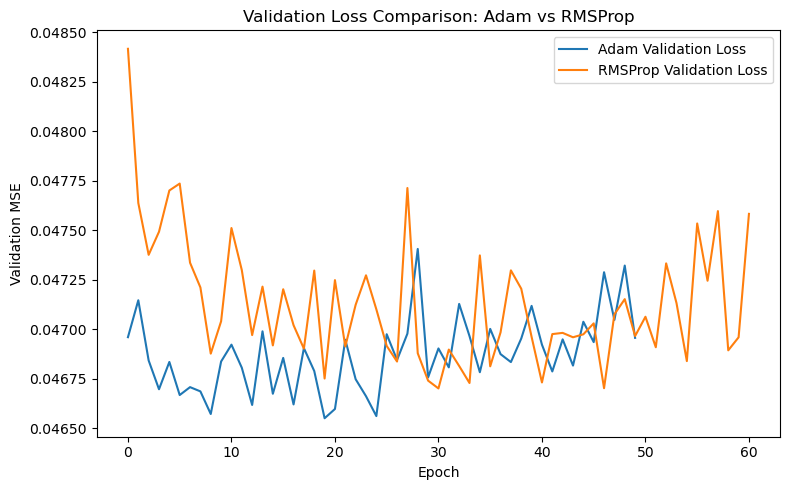

In [61]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["val_loss"],
    label="Adam Validation Loss"
)

plt.plot(
    rms_history.history["val_loss"],
    label="RMSProp Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Validation MSE")

plt.title(
    "Validation Loss Comparison: Adam vs RMSProp"
)

plt.legend()
plt.tight_layout()

plt.savefig(
    "adam_vs_rmsprop_validation_loss.png",
    dpi=300
)

plt.show()

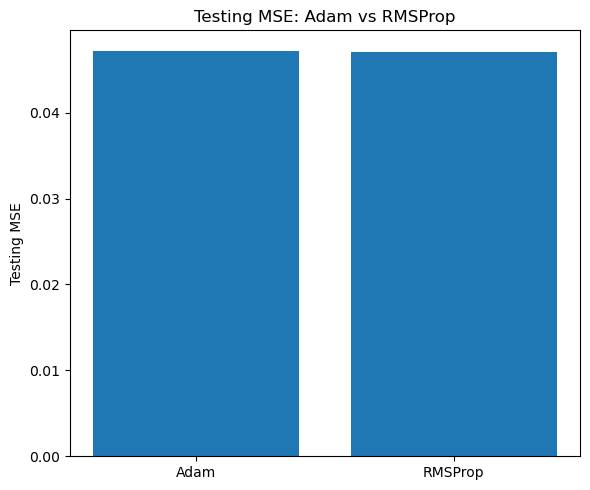

In [62]:
optimizers = ["Adam", "RMSProp"]

testing_mse_values = [
    test_mse,
    rms_test_mse
]

plt.figure(figsize=(6, 5))

plt.bar(
    optimizers,
    testing_mse_values
)

plt.ylabel("Testing MSE")
plt.title("Testing MSE: Adam vs RMSProp")

plt.tight_layout()

plt.savefig(
    "adam_vs_rmsprop_test_mse.png",
    dpi=300
)

plt.show()

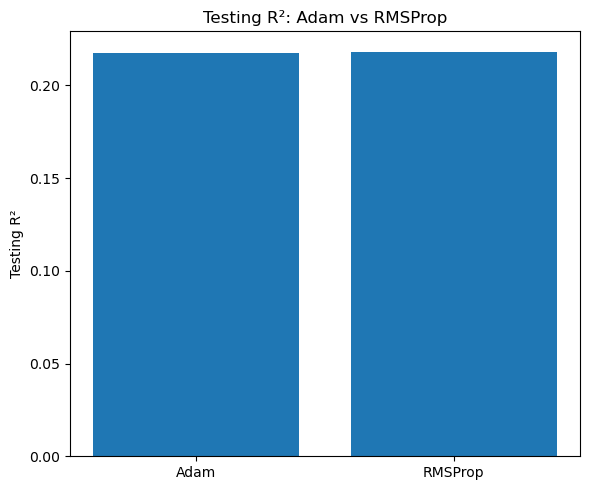

In [63]:
testing_r2_values = [
    test_r2,
    rms_test_r2
]

plt.figure(figsize=(6, 5))

plt.bar(
    optimizers,
    testing_r2_values
)

plt.ylabel("Testing R²")
plt.title("Testing R²: Adam vs RMSProp")

plt.tight_layout()

plt.savefig(
    "adam_vs_rmsprop_test_r2.png",
    dpi=300
)

plt.show()

In [64]:
rms_model.save(
    "prosper_ann_rmsprop.keras"
)

print("RMSProp model saved successfully.")

RMSProp model saved successfully.
